# Winds

In [1]:
import xarray as xr
from tqdm import tqdm 
import glob
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.ndimage import binary_erosion, binary_dilation

# Theory

## **Wind Speed at Staggered Grid Points**

The wind speed magnitude at u-points (east-west faces) and v-points (north-south faces) is computed by interpolating the perpendicular component and applying:

$$
\text{ws}_u = \sqrt{u^2 + v_{\text{on\_u}}^2}, \quad \text{ws}_v = \sqrt{u_{\text{on\_v}}^2 + v^2}
$$

where $v_{\text{on\_u}}$ is $v$ averaged to u-points in the $\xi$ (longitude) direction, and $u_{\text{on\_v}}$ is $u$ averaged to v-points in the $\eta$ (latitude) direction.

## **Surface Wind Stress**

Wind stress components at the staggered grid faces are computed using the bulk formula:

$$
\tau_x^{(u)} = \rho_{\text{air}}\, C_d\, \text{ws}_u \cdot u, \quad \tau_y^{(v)} = \rho_{\text{air}}\, C_d\, \text{ws}_v \cdot v
$$

where:
- $\rho_{\text{air}} = 1.22\,\text{kg}\,\text{m}^{-3}$ is air density,
- $C_d = 1.3 \times 10^{-3}$ is the drag coefficient.

These are then averaged to the rho-points (cell centers):

$$
\tau_x^{(\rho)} = \frac{1}{2}\left(\tau_x^{(u)}_{i} + \tau_x^{(u)}_{i+1}\right), \qquad \tau_y^{(\rho)} = \frac{1}{2}\left(\tau_y^{(v)}_{j} + \tau_y^{(v)}_{j+1}\right)
$$

## **Grid Metrics (Δx, Δy)**

Horizontal grid spacings on the spherical Earth (radius $A = 6{,}371{,}000\,\text{m}$) are:

$$
\Delta x = A\,\cos(\phi)\,\Delta\lambda, \quad \Delta y = A\,\Delta\phi
$$

where $\phi$ is latitude (radians), $\lambda$ is longitude (radians), and $\Delta\lambda$, $\Delta\phi$ are finite differences along $\xi$ and $\eta$ directions.

## **Curl of Wind Stress**

The vertical component of the curl (vorticity of the wind stress) is computed via centered finite differences:

$$
\nabla \times \boldsymbol{\tau} = \frac{\partial \tau_y}{\partial x} - \frac{\partial \tau_x}{\partial y}
$$

Discretized on the interior cell centers:

$$
\bigl(\nabla \times \boldsymbol{\tau}\bigr)_{i,j} = \frac{\tau_y^{(\rho)}_{i+1,j} - \tau_y^{(\rho)}_{i,j}}{\Delta x_{i,j}} - \frac{\tau_x^{(\rho)}_{i,j+1} - \tau_x^{(\rho)}_{i,j}}{\Delta y_{i,j}}
$$

### **Coriolis Parameter**

The Coriolis parameter at cell centers is:

$$
f = 2\,\Omega\,\sin(\phi)
$$

where $\Omega = 7.2921 \times 10^{-5}\,\text{rad}\,\text{s}^{-1}$ is Earth's angular velocity, and $\phi$ is the latitude averaged over the four surrounding rho-points. Values where $|f| < 10^{-10}$ (near the equator) are set to NaN to avoid division by zero.

## **Ekman Pumping Velocity**

The vertical Ekman pumping velocity (positive upward) at the base of the Ekman layer is:

$$
w_{\text{Ek}} = \frac{1}{\rho_w\,f}\,\bigl(\nabla \times \boldsymbol{\tau}\bigr)_z
$$

where $\rho_w = 1025\,\text{kg}\,\text{m}^{-3}$ is seawater density.

## **Cell Area**

The area of each interior cell (for spatial integrals) is:

$$
A_{\text{cell}} = \Delta x \cdot \Delta y
$$

computed at the curl centers by averaging the edge spacings from neighboring cells.

## U ekman cross-shore offshore part
* For the U ekman Cross-shore ($U^{ekman}_{cross-shore}$) we need to grab the offshore boundary.
* Let's give the distance from the coast to the boundary as $L$

### We make some Assumptions

* Alongshore wind stress drives cross-shore Ekman transport in the surface boundary layer of depth δE
* Coordinates: x is offshore (positive seaward), y is alongshore, z is vertical upward with z=0 at the surface and z=−δE at the Ekman base.
* Steady, Boussinesq, hydrostatic, horizontally uniform along y, negligible alongshore pressure gradient within the Ekman layer.
* No vertical turbulent stress at the Ekman base: τy(z=−δE)=0; at surface: τy(z=0)=τy0.
* No-normal-flow at the coast (x=0): u=0. The offshore boundary is at x=L, where the Ekman layer outcrops into the interior; w(x=L, z=−δE)=0.

### Definitions and Assumptions
We consider a surface Ekman layer of depth $\delta_E$.

Coordinates: $x$ offshore, $y$ alongshore, $z$ upward with $z=0$ at the surface and $z=-\delta_E$ at the Ekman base.

Surface stress $\tau_y(0)=\tau_{y0}$, and $\tau_y(-\delta_E)=0$.

Assume steady Boussinesq flow and $w(0)=0$ (after removing surface waves).

### Ekman transport for momentum balance

$$
fu \;=\; \frac{1}{\rho}\,\frac{\partial \tau_y}{\partial z}
$$

Define the transport per unit width
$$
M_E \;\equiv\; \int_{-\delta_E}^{0} u\,dz.
$$

Integrate in $z$:
$$
\int_{-\delta_E}^{0} fu\,dz
= \frac{1}{\rho}\big[\tau_y\big]_{-\delta_E}^{0}
= \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
f\,M_E \;=\; \frac{\tau_{y0}}{\rho}
\;\;\Rightarrow\;\;
M_E \;=\; \frac{\tau_{y0}}{\rho f}.
$$

### Continuity and relation to w at the Ekman base

Incompressibility:
$$
\frac{\partial u}{\partial x}+\frac{\partial w}{\partial z}=0.
$$

Integrate from $z=-\delta_E$ to $z=0$:
$$
\frac{\partial}{\partial x}\!\left(\int_{-\delta_E}^{0}u\,dz\right)
+\Big[w\Big]_{-\delta_E}^{0}=0
\;\;\Rightarrow\;\;
\frac{\partial M_E}{\partial x}=w(-\delta_E)-w(0).
$$

With $w(0)=0$:
$$
w(-\delta_E)=\frac{\partial M_E}{\partial x}.
$$

### Coastal control volume and equivalence
Integrate in $x$ from the coast $x=0$ (no-normal-flow $\Rightarrow M_E(0)=0$) to $x=L$:
$$
M_E(L)-M_E(0)=\int_{0}^{L} w(-\delta_E)\,dx
\;\;\Rightarrow\;\;
M_E(L)=\int_{0}^{L} w_b\,dx,
$$
where $w_b\equiv w(-\delta_E)$ and, if approximately uniform over $[0,L]$,
$$
M_E(L)=w_b\,L.
$$

Using $M_E(L)=\dfrac{\tau_{y0}}{\rho f}$ gives
$$
w_b\,L=\frac{\tau_{y0}}{\rho f}
\quad\Rightarrow\quad
\boxed{\,w_b=\dfrac{1}{L}\,\dfrac{\tau_{y0}}{\rho f}\, }.
$$

Then we need to calculate the $Ek_{t}$ at the offshore part of $L$ as it is the equivalent of the $w_b$

Then let $Ek_c$ be:

\begin{equation}
\tau_{\text{alongshore}} = \sin(\alpha)\,\tau_{y} + \cos(\alpha)\,\tau_{x}
\end{equation}

# Functions

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Dataset

In [4]:
winds_ds = xr.open_dataset('winds_NHUS.nc').compute()
winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

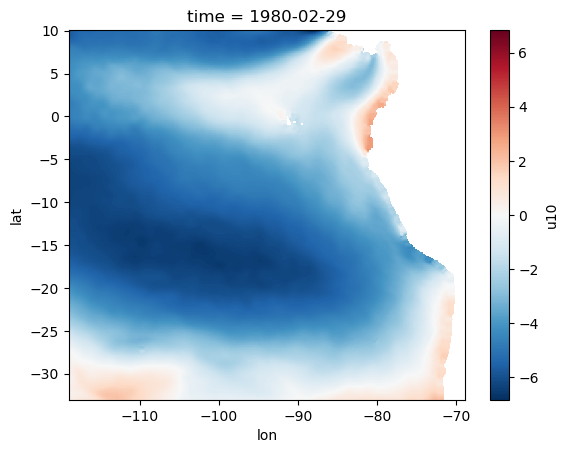

In [5]:
winds_ds.isel(time=1).u10.plot()

## Coastal angle calculation

In [6]:
# Load your CROCO grid
ds = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [7]:
mask = ds['mask_rho'].values  # 1=ocean, 0=land
lon  = ds['lon_rho'].values
lat  = ds['lat_rho'].values

Total coastal points found: 542
Coastal lat range: -33.00 to 10.03
Coastal lon range: -85.78 to -70.20

Points in 5S-16S: 134
Lon range in domain: -81.20 to -74.20
Lat range in domain: -15.95 to -5.08

Linear fit R²    = 0.986
Coastline angle  = -29.7° from north
|alpha| to use   = 29.7°


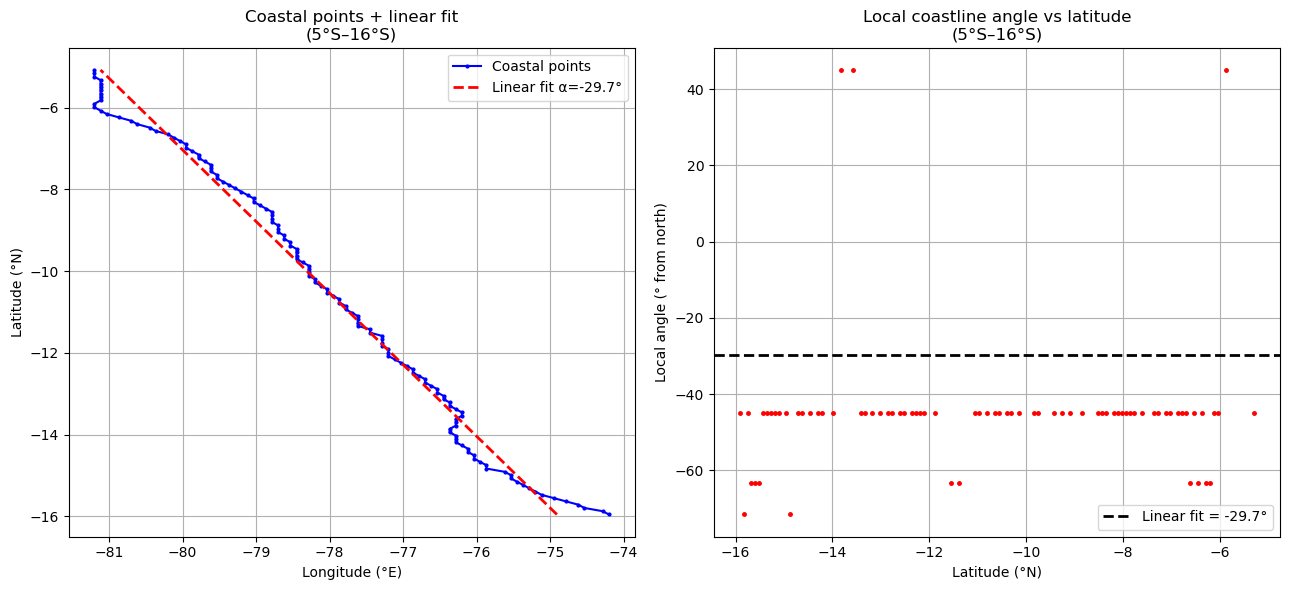

In [8]:
# --- Step 1: Search from EAST (high xi index) to find Peru coast ---
coast_lon_list = []
coast_lat_list = []

for j in range(mask.shape[0]):          # axis 0 = N-S
    row = mask[j, :]
    ocean_cols = np.where(row == 1)[0]
    if len(ocean_cols) == 0:
        continue
    i = ocean_cols[-1]                  # EASTERNMOST ocean point ← key fix
    coast_lon_list.append(lon[j, i])
    coast_lat_list.append(lat[j, i])

coast_lon = np.array(coast_lon_list)
coast_lat = np.array(coast_lat_list)

print(f"Total coastal points found: {len(coast_lon)}")
print(f"Coastal lat range: {coast_lat.min():.2f} to {coast_lat.max():.2f}")
print(f"Coastal lon range: {coast_lon.min():.2f} to {coast_lon.max():.2f}")

# --- Step 2: Filter to 5S-16S ---
domain_mask = (coast_lat >= -16.0) & (coast_lat <= -5.0)
coast_lon_d  = coast_lon[domain_mask]
coast_lat_d  = coast_lat[domain_mask]

print(f"\nPoints in 5S-16S: {len(coast_lon_d)}")
print(f"Lon range in domain: {coast_lon_d.min():.2f} to {coast_lon_d.max():.2f}")
print(f"Lat range in domain: {coast_lat_d.min():.2f} to {coast_lat_d.max():.2f}")

# --- Step 3: Linear fit ---
deg2m   = 111000.0
x_coast = coast_lon_d * deg2m * np.cos(np.radians(np.mean(coast_lat_d)))
y_coast = coast_lat_d * deg2m

slope, intercept, r, p, se = linregress(y_coast, x_coast)
alpha_fit = np.degrees(np.arctan(slope))

print(f"\nLinear fit R²    = {r**2:.3f}")
print(f"Coastline angle  = {alpha_fit:.1f}° from north")
print(f"|alpha| to use   = {abs(alpha_fit):.1f}°")

# --- Step 4: Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

lat_fit = np.linspace(coast_lat_d.min(), coast_lat_d.max(), 200)
lon_fit = np.mean(coast_lon_d) + np.tan(np.radians(alpha_fit)) * \
          (lat_fit - np.mean(coast_lat_d))

ax1.plot(coast_lon_d, coast_lat_d, 'b.-', ms=4, label='Coastal points')
ax1.plot(lon_fit, lat_fit, 'r--', lw=2, label=f'Linear fit α={alpha_fit:.1f}°')
ax1.set_xlabel('Longitude (°E)')
ax1.set_ylabel('Latitude (°N)')
ax1.set_title('Coastal points + linear fit\n(5°S–16°S)')
ax1.legend(); ax1.grid(True)

mid_lat     = 0.5 * (coast_lat_d[:-1] + coast_lat_d[1:])
dx_local    = np.diff(coast_lon_d) * deg2m * np.cos(np.radians(mid_lat))
dy_local    = np.diff(coast_lat_d) * deg2m
alpha_local = np.degrees(np.arctan2(dx_local, dy_local))
valid       = np.abs(alpha_local) > 1.0

ax2.plot(mid_lat[valid], alpha_local[valid], 'r.', ms=5)
ax2.axhline(alpha_fit, color='k', linestyle='--', lw=2,
            label=f'Linear fit = {alpha_fit:.1f}°')
ax2.set_xlabel('Latitude (°N)')
ax2.set_ylabel('Local angle (° from north)')
ax2.set_title('Local coastline angle vs latitude\n(5°S–16°S)')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
# plt.savefig('coastline_angle_final.png', dpi=150)
plt.show()

In [9]:
# plt.plot(mid_lat,alpha_local,marker='.')
import pandas as pd
df_all = pd.DataFrame({
    'latitude':    mid_lat,
    'alpha_deg':   alpha_local
})
df_all= np.abs(df_all)
df_all.describe()

,latitude,alpha_deg
count,133.000000,133.000000
mean,10.547254,27.701766
std,3.153926,24.320143
min,5.117460,0.000000
25%,7.849382,0.000000
50%,10.563373,45.002584
75%,13.253515,45.004553
max,15.914151,71.568465


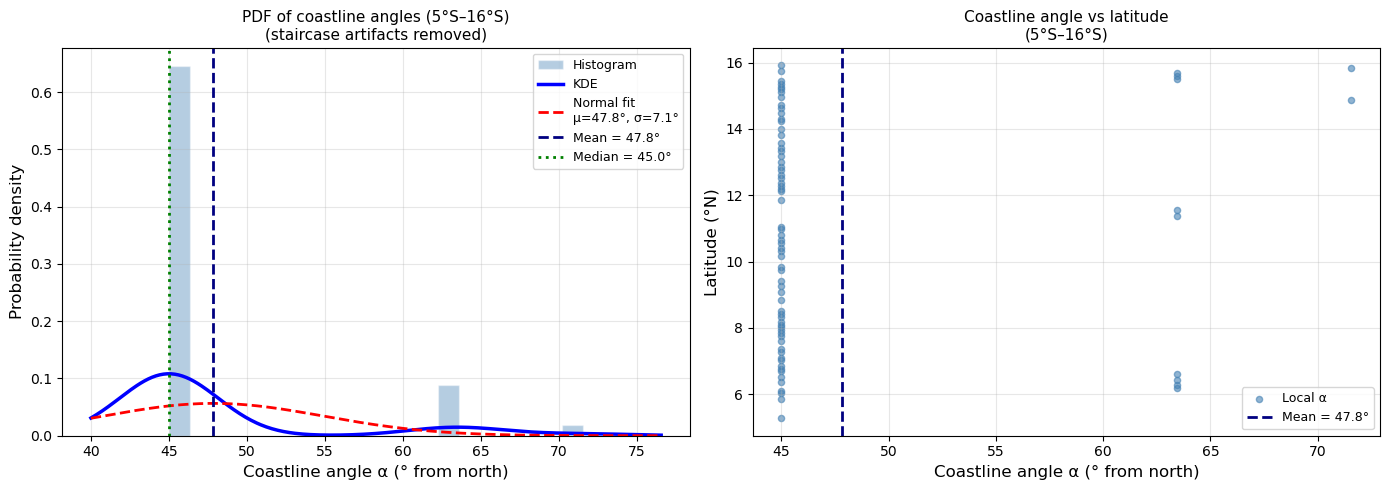


=== RECOMMENDED VALUE FOR PAPER ===
Mean alpha:        47.8°
Median alpha:      45.0044°


In [10]:
from scipy.stats import gaussian_kde, norm
# --- Use ALL angles (not just valid) so you can see the full distribution ---
# But also prepare filtered version (no staircase zeros)
# df_all      = pd.DataFrame({'latitude': mid_lat,     'alpha_deg': alpha_local})
df_filtered = df_all[np.abs(df_all['alpha_deg']) > 1.0].copy()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left panel: PDF with KDE ----
ax = axes[0]
angles = df_filtered['alpha_deg'].values

# Histogram
ax.hist(angles, bins=20, density=True, alpha=0.4,
        color='steelblue', edgecolor='white', label='Histogram')

# KDE (smooth PDF)
kde  = gaussian_kde(angles, bw_method='silverman')
x_range = np.linspace(angles.min() - 5, angles.max() + 5, 300)
ax.plot(x_range, kde(x_range), 'b-', lw=2.5, label='KDE')

# Normal fit
mu, sigma = norm.fit(angles)
ax.plot(x_range, norm.pdf(x_range, mu, sigma), 'r--', lw=2,
        label=f'Normal fit\nμ={mu:.1f}°, σ={sigma:.1f}°')

# Mark mean, median, linear fit
ax.axvline(df_filtered['alpha_deg'].mean(),   color='navy',   lw=2,
           linestyle='--', label=f'Mean = {df_filtered["alpha_deg"].mean():.1f}°')
ax.axvline(df_filtered['alpha_deg'].median(), color='green',  lw=2,
           linestyle=':',  label=f'Median = {df_filtered["alpha_deg"].median():.1f}°')
# ax.axvline(alpha_fit,                          color='red',    lw=2,
#            linestyle='-',  label=f'Linear fit = {alpha_fit:.1f}°')

ax.set_xlabel('Coastline angle α (° from north)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title('PDF of coastline angles (5°S–16°S)\n(staircase artifacts removed)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Right panel: Alpha vs Latitude (spatial view) ----
ax2 = axes[1]
ax2.scatter(df_filtered['alpha_deg'], df_filtered['latitude'],
            c='steelblue', s=20, alpha=0.6, label='Local α')
ax2.axvline(df_filtered['alpha_deg'].mean(),   color='navy',  lw=2,
            linestyle='--', label=f'Mean = {df_filtered["alpha_deg"].mean():.1f}°')
# ax2.axvline(alpha_fit,                          color='red',   lw=2,
#             linestyle='-',  label=f'Linear fit = {alpha_fit:.1f}°')
ax2.set_xlabel('Coastline angle α (° from north)', fontsize=12)
ax2.set_ylabel('Latitude (°N)', fontsize=12)
ax2.set_title('Coastline angle vs latitude\n(5°S–16°S)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('alpha_PDF.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Final recommendation ---
print(f"\n=== RECOMMENDED VALUE FOR PAPER ===")
# print(f"Linear fit alpha:  {alpha_fit:.1f}°")
print(f"Mean alpha:        {df_filtered['alpha_deg'].mean():.1f}°")
print(f"Median alpha:      {df_filtered['alpha_deg'].median():.4f}°")
# print(f"Use in paper:      α ≈ {round(alpha_fit/5)*5:.0f}° (rounded to nearest 5°)")

## Uekman calculation

In [11]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10

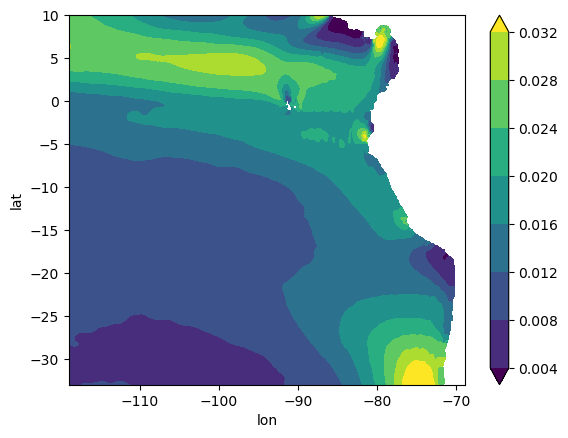

In [12]:
tauy.std('time').plot.contourf(robust=True)

In [13]:
# rho_sw = 1025
# winds_ds['Uek_geo'] = tauy/(rho_sw*f)
# winds_ds['Vek_geo'] = taux/(rho_sw*f)

In [14]:
# mask = coastal_band_mask(winds_ds, var='Uek_geo', iterations=10)
# ss = winds_ds.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5)) 
# ss 

In [15]:
# ss.Uek_geo.sel(lat=slice(-16,-5)).std('time').plot.contourf(robust=True)

In [16]:
alpha = 30

tau_alongshore = np.sin(alpha) * tauy + np.cos(alpha) * taux
tau_alongshore

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[ 3.23254000e-03,  3.35122391e-03,  3.48195025e-03, ...,
                     nan,             nan,             nan],
        [ 3.31195679e-03,  3.44107587e-03,  3.58121219e-03, ...,
                     nan,             nan,             nan],
        [ 3.37878108e-03,  3.51915739e-03,  3.66859511e-03, ...,
                     nan,             nan,             nan],
        ...,
        [ 1.04238756e-02,  1.03569969e-02,  1.03291907e-02, ...,
                     nan,             nan,             nan],
        [ 1.05877679e-02,  1.05213498e-02,  1.04898737e-02, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 2.63740166e-03,  2.82286041e-03,  3.00100992e-03, ...,
                     nan,             nan,             nan],
        [ 2.67853682e-03,  2.85511987e-03,  3.02371302e-03, ...,
                     nan,             nan,             nan],
        [ 2.71053498e-03,  2.87596844e-03,  3.03272908e-03, ...,
                     nan,             nan,             nan],
...
        [-1.11196741e-04, -1.13235221e-04, -1.14678291e-04, ...,
                     nan,             nan,             nan],
        [-6.01977545e-05, -6.16327156e-05, -6.27134238e-05, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-6.71396676e-04, -6.09128192e-04, -5.47119879e-04, ...,
                     nan,             nan,             nan],
        [-6.88542554e-04, -6.27523418e-04, -5.65590596e-04, ...,
                     nan,             nan,             nan],
        [-7.06466312e-04, -6.46936577e-04, -5.85362268e-04, ...,
                     nan,             nan,             nan],
        ...,
        [ 3.22428321e-02,  3.16925860e-02,  3.11668110e-02, ...,
                     nan,             nan,             nan],
        [ 3.39112728e-02,  3.33467262e-02,  3.28015198e-02, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

In [17]:
winds_ds['tau_alongshore'] = tau_alongshore
winds_ds

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon             (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat             (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time            (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10             (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan
    v10             (time, lat, lon) float64 1GB -0.9696 -0.999 ... nan nan
    tau_alongshore  (time, lat, lon) float64 1GB 0.003233 0.003351 ... nan nan

In [18]:
mask = coastal_band_mask(winds_ds, var='tau_alongshore', iterations=10)

In [19]:
wind_coastal = winds_ds.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5)) 
wind_coastal# applies to all variables

<xarray.Dataset> Size: 270MB
Dimensions:         (time: 432, lat: 134, lon: 194)
Coordinates:
  * lon             (lon) float64 2kB -84.95 -84.87 -84.78 ... -68.95 -68.87
  * lat             (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
  * time            (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10             (time, lat, lon) float64 90MB nan nan nan ... nan nan nan
    v10             (time, lat, lon) float64 90MB nan nan nan ... nan nan nan
    tau_alongshore  (time, lat, lon) float64 90MB nan nan nan ... nan nan nan

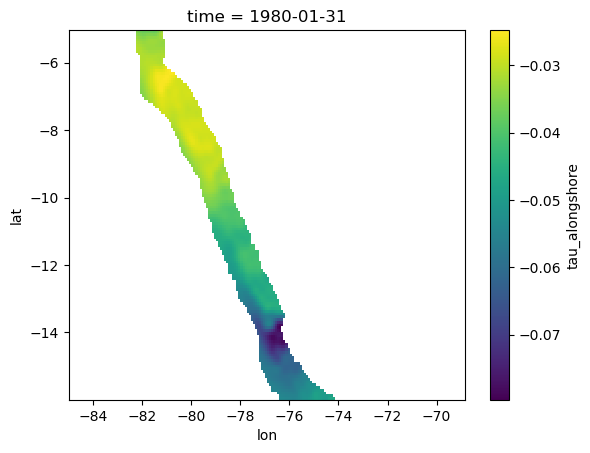

In [20]:
wind_coastal.tau_alongshore.isel(time=0).plot()

## Ekman transport
* Ekman transport or Uekman or BUI
* offshore at the last cell at 111km
* Inshore for Wc (AV) first cell at $x=0$

In [21]:
rho_sw = 1025

BUI = wind_coastal.tau_alongshore / (rho_sw * f)

In [22]:
#### Offshore
valid = xr.where(np.isfinite(BUI), 1, 0)
valid_e = valid.shift(lon=+1)  # east

offshore_mask = (valid == 1) & (valid_e == 0)

offshore_border = BUI.where(offshore_mask)

#### Inshore
valid = xr.where(np.isfinite(BUI), 1, 0)
valid_w = valid.shift(lon=-1) #west
# Boolean mask of valid ocean cells
valid_in = xr.where(np.isfinite(BUI), 1, 0)
# valid_e = valid.shift(lon=+1)  # east

inshore_mask = (valid_in == 1) & (valid_w == 0)

inshore_border = BUI.where(inshore_mask)

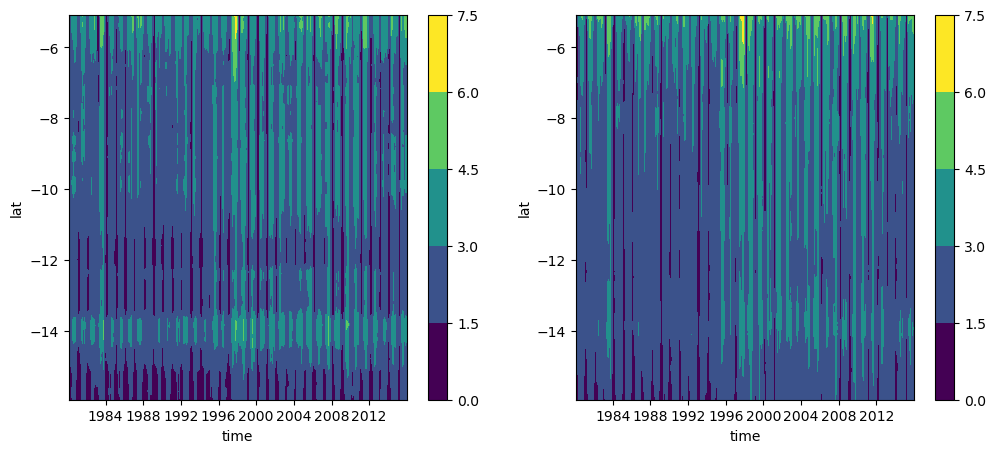

In [23]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
inshore_border.mean(dim='lon').plot.contourf(y='lat',ax=ax[0])
offshore_border.mean(dim='lon').plot.contourf(y='lat',ax=ax[1])

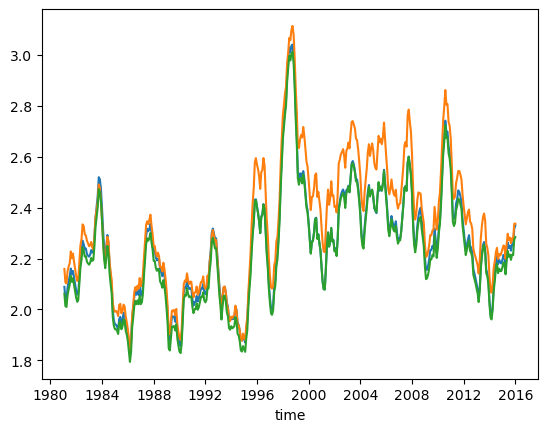

In [24]:
inshore_border.mean(dim=('lon','lat')).rolling(time=13).mean().plot()
offshore_border.mean(dim=('lon','lat')).rolling(time=13).mean().plot()
BUI.mean(dim=('lon','lat')).rolling(time=13).mean().plot()

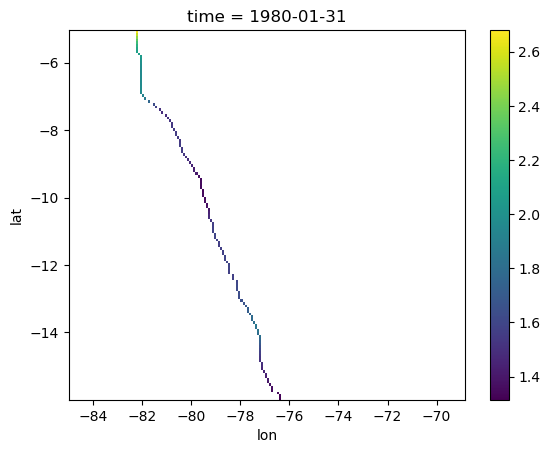

In [25]:
offshore_border.isel(time=0).plot()

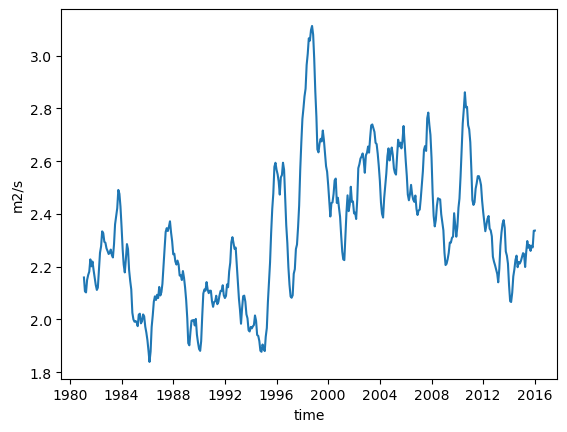

In [26]:
offshore_border.mean(dim=('lat','lon')).rolling(time=13).mean().rename('m2/s').plot()

In [27]:
# d = 111*1000 #111km
d = (10/12)*111*1000
BUI_ms = offshore_border/d

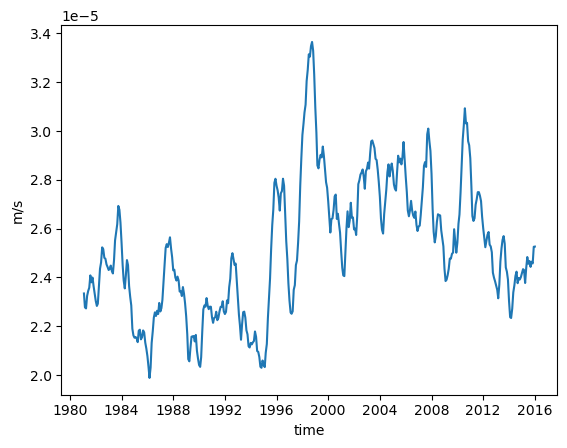

In [28]:
BUI_ms.mean(dim=('lat','lon')).rolling(time=13).mean().rename('m/s').plot()

## Comparison with Modelled W

In [29]:
wmld = xr.open_dataset('W_mld_Croco.nc')
wmld

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    WMLD     (time, lat, lon) float64 1GB ...

In [30]:
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-16,-5))
wmld

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 432, lat: 134, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
Data variables:
    WMLD     (time, lat, lon) float64 90MB nan nan nan nan ... nan nan nan nan

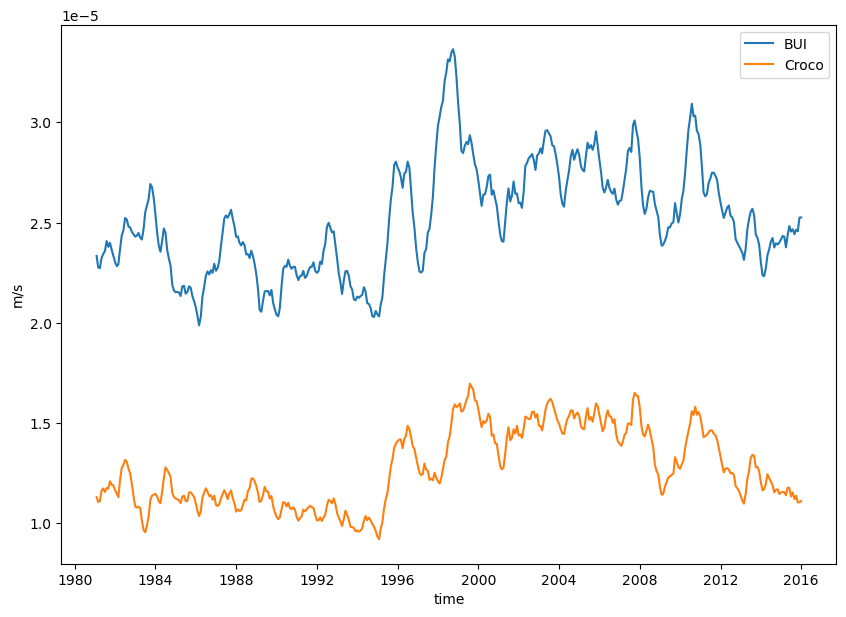

In [31]:
# wmld.WMLD.isel(time=0).plot()
(BUI_ms.mean(dim=('lat','lon'))).rolling(time=13).mean().rename('m/s').plot(label='BUI',figsize=(10,7))
wmld.WMLD.mean(dim=('lat','lon')).rolling(time=13).mean().rename('m/s').plot(label='Croco')
plt.legend()

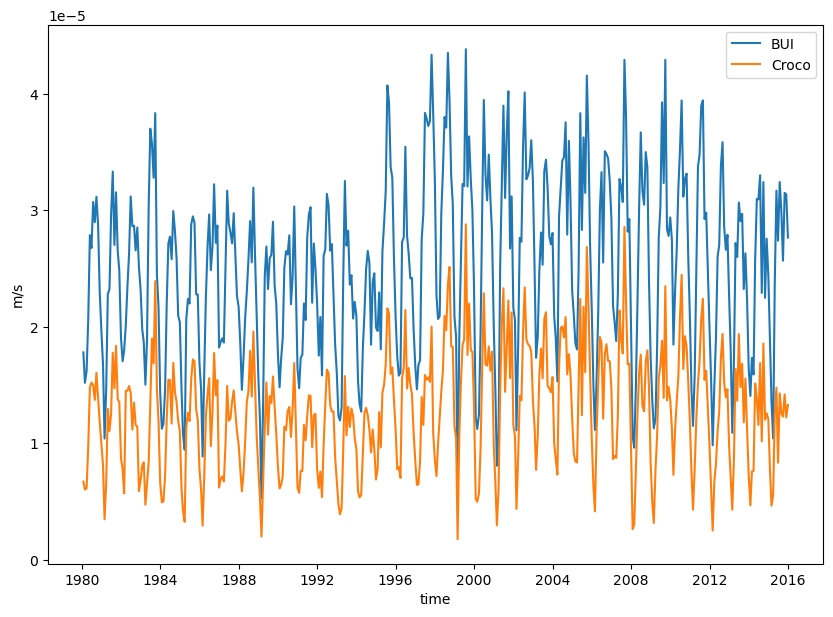

In [32]:
(BUI_ms.mean(dim=('lat','lon'))).rename('m/s').plot(label='BUI',figsize=(10,7))
wmld.WMLD.mean(dim=('lat','lon')).rename('m/s').plot(label='Croco')
plt.legend()

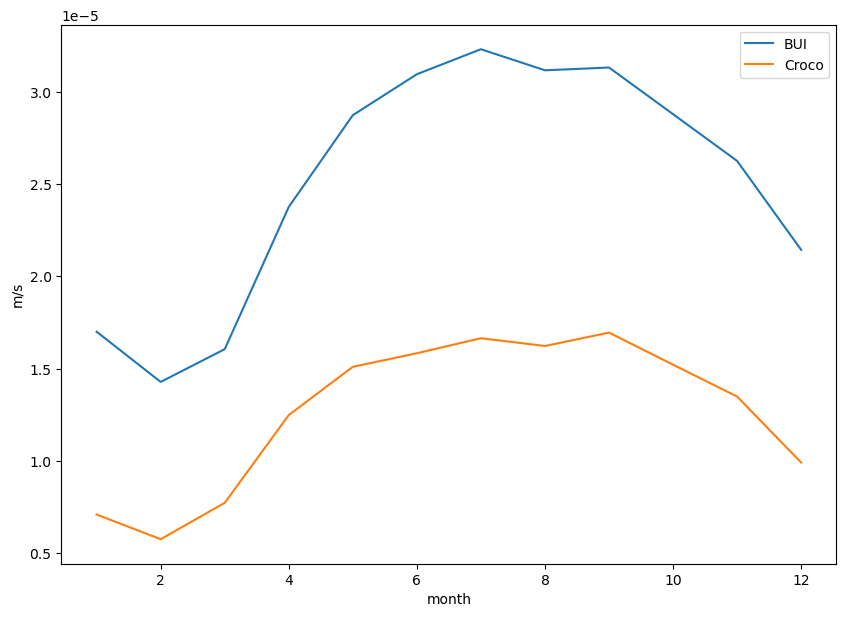

In [33]:
seasonality((BUI_ms.mean(dim=('lat','lon')))).rename('m/s').plot(label='BUI',figsize=(10,7))
seasonality(wmld.WMLD.mean(dim=('lat','lon'))).rename('m/s').plot(label='Croco')
plt.legend()

* Winds blow stronger during the austral winter, and BUI captures the wind effect. Croco includes the u geostrophic that can contrarest the winds
* BUI is very sensitive to the angle and the L, we recommend to take the median instead of the mean

In [34]:
# offshore_border.to_netcdf('BUI.nc')

In [35]:
offshore_border.rename('Uekman_crosshore')

<xarray.DataArray 'Uekman_crosshore' (time: 432, lat: 134, lon: 194)> Size: 90MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.242 -5.159 -5.076
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

## Ekman geographic

In [36]:
winds_ds

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon             (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat             (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * time            (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10             (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan
    v10             (time, lat, lon) float64 1GB -0.9696 -0.999 ... nan nan
    tau_alongshore  (time, lat, lon) float64 1GB 0.003233 0.003351 ... nan nan

In [37]:
winds_ds['Uekman_Crossshore'] = offshore_border.rename('Uekman_crosshore')
winds_ds['Inshore_Uekman'] = inshore_border.rename('Inshore_Uekman')
winds_ds['Uek_geo'] = tauy/(rho_sw*f)
winds_ds['Vek_geo'] = taux/(rho_sw*f)
winds_ds['f'] = f
winds_ds.to_netcdf('winds_and_components_alpha_30.nc')

# Ekman Pumping

In [38]:
from tqdm import tqdm

A = 6371000.0
rho_air = 1.22
Cd = 1.3e-3
rho_w = 1025.0
Omega = 7.2921e-5

In [39]:
delta_y = np.deg2rad(winds_ds.lat.shift(lat=-1) - winds_ds.lat) * A
delta_x = (
    np.deg2rad(winds_ds.lon.shift(lon=-1) - winds_ds.lon) * A
    * np.cos(np.deg2rad(winds_ds.lat))
)

dtauy_by_dx = (tauy.shift(lon=-1) - tauy) / delta_x
dtauy_by_dx = (dtauy_by_dx.shift(lat=-1) + dtauy_by_dx) / 2.0

dtaux_by_dy = (taux.shift(lat=-1) - taux) / delta_y
dtaux_by_dy = (dtaux_by_dy.shift(lon=-1) + dtaux_by_dy) / 2.0

lon1 = (winds_ds.lon.shift(lon=-1) + winds_ds.lon) / 2
lat1 = (winds_ds.lat.shift(lat=-1) + winds_ds.lat) / 2

dtaux_by_dy = dtaux_by_dy.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))
dtauy_by_dx = dtauy_by_dx.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))

curlz_tau = (dtauy_by_dx - dtaux_by_dy)

f = 2 * 7.2921e-5 * np.sin(np.deg2rad(curlz_tau.lat))
rho = 1025

w_ek = (1/f/rho) * curlz_tau

w_ek = w_ek.transpose('time','lat','lon')
w_ek

<xarray.DataArray (time: 432, lat: 541, lon: 601)> Size: 1GB
array([[[ 2.72424435e-07,  3.15049249e-07,  3.46992220e-07, ...,
                     nan,             nan,             nan],
        [ 2.69494222e-07,  3.09872783e-07,  3.36117293e-07, ...,
                     nan,             nan,             nan],
        [ 2.60582631e-07,  2.96705216e-07,  3.16600183e-07, ...,
                     nan,             nan,             nan],
        ...,
        [-1.07519679e-07, -2.09001497e-07, -1.86646631e-07, ...,
                     nan,             nan,             nan],
        [-2.38697647e-07, -3.32612218e-07, -3.11489473e-07, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 2.49513510e-07,  2.39869719e-07,  2.24505258e-07, ...,
                     nan,             nan,             nan],
        [ 2.40636757e-07,  2.26566192e-07,  2.10605824e-07, ...,
                     nan,             nan,             nan],
        [ 2.27014849e-07,  2.11650754e-07,  1.98003447e-07, ...,
                     nan,             nan,             nan],
...
        [ 1.94535802e-08,  1.85697773e-08,  2.42230336e-08, ...,
                     nan,             nan,             nan],
        [ 4.55052992e-09,  3.81081672e-09,  8.18491203e-09, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 4.16830108e-08,  4.67495481e-08,  4.91892179e-08, ...,
                     nan,             nan,             nan],
        [ 3.94522591e-08,  4.50353188e-08,  4.84285871e-08, ...,
                     nan,             nan,             nan],
        [ 3.94275450e-08,  4.64486001e-08,  5.14865957e-08, ...,
                     nan,             nan,             nan],
        ...,
        [ 7.74884637e-06,  7.68380580e-06,  7.74123803e-06, ...,
                     nan,             nan,             nan],
        [ 7.73282744e-06,  7.72981215e-06,  7.84915310e-06, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91

In [40]:
w_ek = w_ek.to_dataset(name = 'w_ek').transpose('time','lat','lon')
print(w_ek)

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 541, time: 432, lon: 601)
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
Data variables:
    w_ek     (time, lat, lon) float64 1GB 2.724e-07 3.15e-07 ... nan nan


In [41]:
mask_pump = coastal_band_mask(w_ek, var='w_ek', iterations=10)

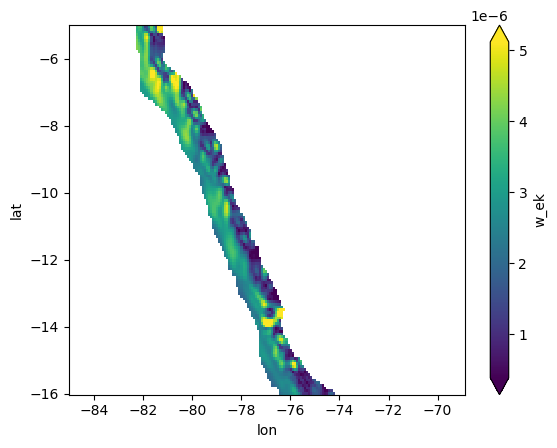

In [42]:
w_ek.where(mask_pump).w_ek.sel(lon=slice(-85,None),lat=slice(-16,-5)).std('time').plot(robust=True)

In [43]:
# w_ek.to_netcdf('Ekman_pumping.nc')